# Calibrated Binary Classifier - Fraud Detection Demo

This notebook demonstrates:
1. **IEEE Fraud Detection** dataset loading and preprocessing
2. **CalibratedBinaryClassifier** with automated feature engineering
3. **Calibration comparison**: Isotonic vs Venn-ABERS vs Sigmoid
4. **Prediction intervals** with Venn-ABERS for uncertainty quantification
5. **Model evaluation** with proper metrics for imbalanced data

In [1]:
# Setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    classification_report
)
from sklearn.calibration import calibration_curve

from calibrated_clf import CalibratedBinaryClassifier

import warnings
warnings.filterwarnings('ignore')

# Plotting setup
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

%load_ext autoreload
%autoreload 2

## 1. Load IEEE Fraud Detection Data

In [2]:
from calibrated_clf.data_loader import load_fraud_data, create_time_groups

print("Loading IEEE Fraud Detection dataset...")
df = load_fraud_data(sample_frac=None, verbose=True)

print(f"\nDataset shape: {df.shape}")
print(f"Fraud rate: {df['isFraud'].mean():.2%}")
print(f"Features: {df.shape[1] - 1}")

Loading IEEE Fraud Detection dataset...
Loading IEEE Fraud Detection Dataset

📂 Loading transactions from: ieee-fraud-detection/train_transaction.csv
   ✓ Loaded 590,540 transactions with 394 features
   ✓ Fraud rate: 3.50%

📂 Loading identity data from: ieee-fraud-detection/train_identity.csv
   ✓ Loaded 144,233 identity records with 41 features
   ✓ Identity coverage: 24.4% of transactions

🔗 Merging transaction and identity data...
   ✓ Merged shape: (590540, 434)
   ✓ Missing values: 115,523,073 (45.1%)

✅ Data loading complete!
   Final shape: (590540, 434)

Dataset shape: (590540, 434)
Fraud rate: 3.50%
Features: 433


In [3]:
# Create time groups for temporal validation
df['time_group'] = create_time_groups(df, n_bins=50, verbose=True)

# Quick EDA
print("\nBasic Statistics:")
print(df[['TransactionAmt', 'TransactionDT', 'isFraud']].describe())


⏰ Creating time groups from 'TransactionDT'...
   Time range: 86400 to 15811131
   Duration: 15,724,731 seconds (~182.0 days)
   ✓ Created 50 time groups (requested: 50)
   ✓ Method: quantile
   ✓ Samples per group: min=11810, mean=11811, max=11812

Basic Statistics:
       TransactionAmt  TransactionDT        isFraud
count   590540.000000   5.905400e+05  590540.000000
mean       135.027176   7.372311e+06       0.034990
std        239.162522   4.617224e+06       0.183755
min          0.251000   8.640000e+04       0.000000
25%         43.321000   3.027058e+06       0.000000
50%         68.769000   7.306528e+06       0.000000
75%        125.000000   1.124662e+07       0.000000
max      31937.391000   1.581113e+07       1.000000


## 2. Prepare Data for Modeling

In [4]:
# Separate features and target
X = df.drop(columns=['isFraud', 'TransactionID', 'time_group'])
y = df['isFraud']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns[:10])}...")

Features shape: (590540, 432)
Target shape: (590540,)

Feature columns: ['TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1']...


In [5]:
# Temporal split (train on early data, test on later data)
time_split = df['TransactionDT'].quantile(0.7)
train_mask = df['TransactionDT'] < time_split
test_mask = df['TransactionDT'] >= time_split

X_train = X[train_mask].reset_index(drop=True)
X_test = X[test_mask].reset_index(drop=True)
y_train = y[train_mask].reset_index(drop=True)
y_test = y[test_mask].reset_index(drop=True)

print(f"Train set: {len(X_train):,} transactions ({y_train.mean():.2%} fraud)")
print(f"Test set: {len(X_test):,} transactions ({y_test.mean():.2%} fraud)")

Train set: 413,378 transactions (3.52% fraud)
Test set: 177,162 transactions (3.46% fraud)


In [6]:
from calibrated_clf.data_transformers import FraudFeatureEngineer

# Feature engineering — stateful to prevent group leakage:
# group statistics (e.g. mean TransactionAmt per card1) are fitted on the
# training set only and then applied to the test set via transform().
n_original = X_train.shape[1]

engineer = FraudFeatureEngineer()
X_train = engineer.fit_transform(X_train)   # fit + transform on train
X_test  = engineer.transform(X_test)        # transform test using TRAIN stats (no leakage)

print(f"Original features:  {n_original}")
print(f"Engineered — Train: {X_train.shape}, Test: {X_test.shape}")
print(f"New features added: {X_train.shape[1] - n_original}")


Original features:  432
Engineered — Train: (413378, 445), Test: (177162, 445)
New features added: 13


## 3. Train Models with Different Calibration Methods

We'll compare three calibration methods:
1. **Isotonic Regression** - Standard sklearn calibration
2. **Venn-ABERS** - Conformal prediction with intervals
3. **Sigmoid (Platt Scaling)** - Logistic regression calibration

In [7]:
# Model hyperparameters — tuned with Optuna (100 trials, AUC-PR=0.583)
# See fraud_detection_optimization.db for full study results
model_params = {
    'classifier__boosting_type': 'gbdt',
    'classifier__learning_rate': 0.19295442631893386,
    'classifier__max_depth': 7,
    'classifier__reg_alpha': 6.822213427683418e-05,
    'classifier__reg_lambda': 7.520511192442875e-08,
    'classifier__n_estimators': 106,
    'classifier__min_split_gain': 0.0004901345350576661,
    'classifier__colsample_bytree': 0.7230646752900232,
    'classifier__num_leaves': 95,
    'cat_encoder__strategy': 'm_estimate'
}

print("Training models with different calibration methods...\n")

Training models with different calibration methods...



### 3.1 Hyperparameter Optimization (Optional)

For best performance, we can use **Optuna** to find optimal hyperparameters. This section demonstrates how to run hyperparameter optimization before training.

🔍 Running hyperparameter optimization with Optuna...
   Features: 445
   Categorical: 31
   Samples: 413,378


[I 2026-03-10 22:47:30,477] A new study created in RDB with name: fraud_detection_optimization


📁 Study stored in fraud_detection_optimization.db


[I 2026-03-10 22:48:08,287] Trial 0 finished with value: 0.18138111810094845 and parameters: {'classifier__boosting_type': 'goss', 'classifier__learning_rate': 0.0019001378310786235, 'classifier__max_depth': 7, 'classifier__reg_alpha': 1287.6421278272737, 'classifier__reg_lambda': 0.0010566170924553512, 'classifier__n_estimators': 157, 'classifier__min_split_gain': 2.4232910956987616e-05, 'classifier__colsample_bytree': 0.5526837284785868, 'classifier__num_leaves': 90, 'classifier__top_rate': 0.3589733665689161, 'classifier__other_rate': 0.4314742423537718, 'cat_encoder__strategy': 'm_estimate'}. Best is trial 0 with value: 0.18138111810094845.
[I 2026-03-10 22:48:45,153] Trial 1 finished with value: 0.5162117959783775 and parameters: {'classifier__boosting_type': 'gbdt', 'classifier__learning_rate': 0.0674108695521717, 'classifier__max_depth': 5, 'classifier__reg_alpha': 1.9021414993694328e-08, 'classifier__reg_lambda': 2.7575130607356735e-08, 'classifier__n_estimators': 160, 'classif

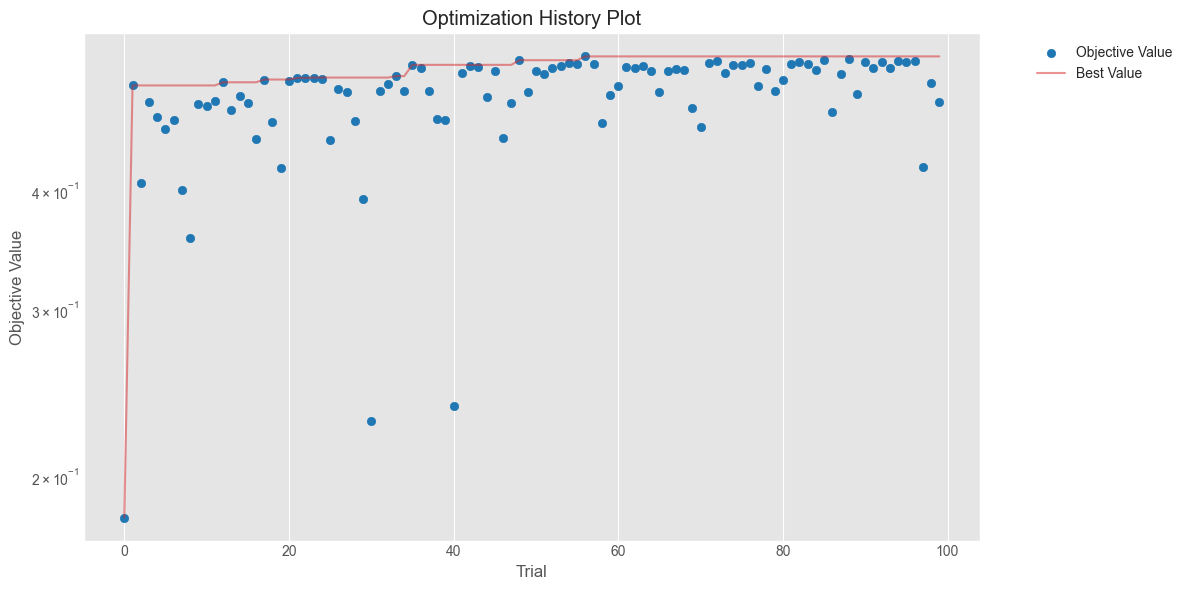

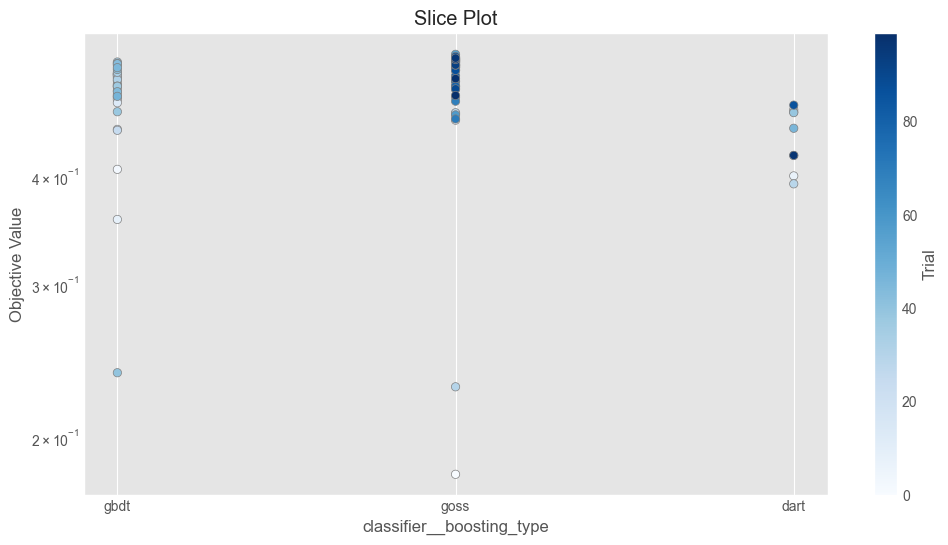

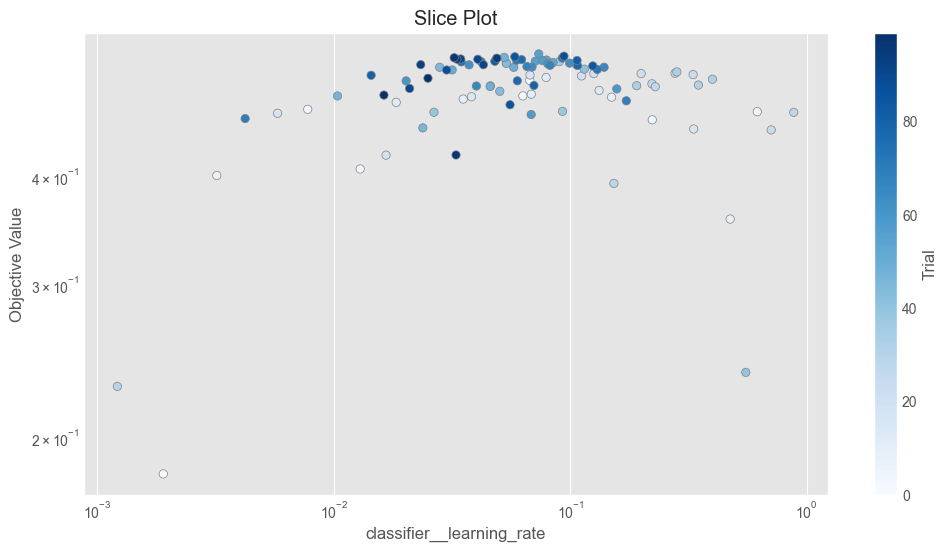

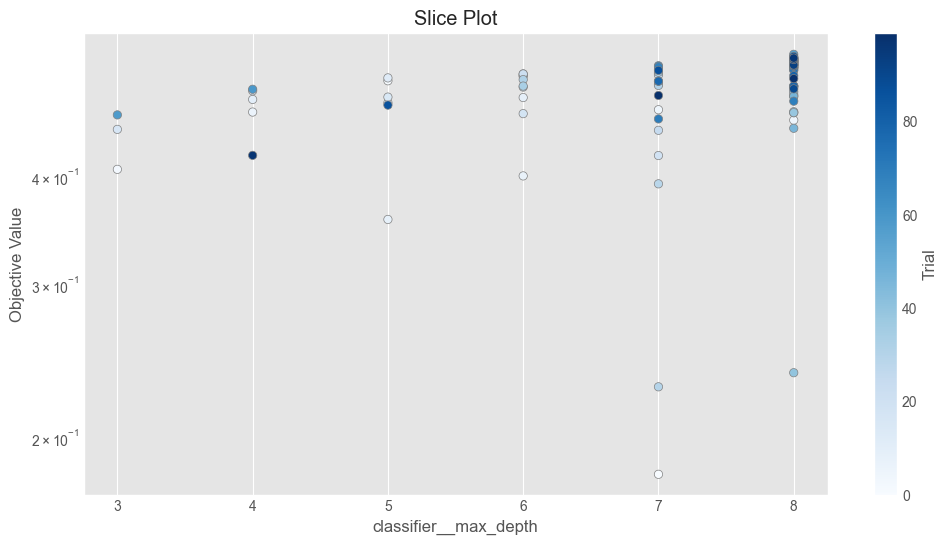

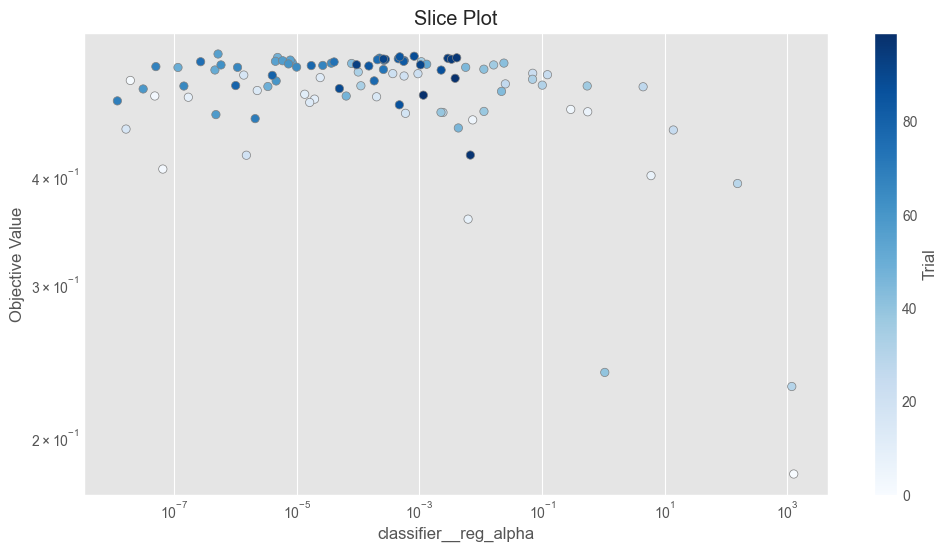

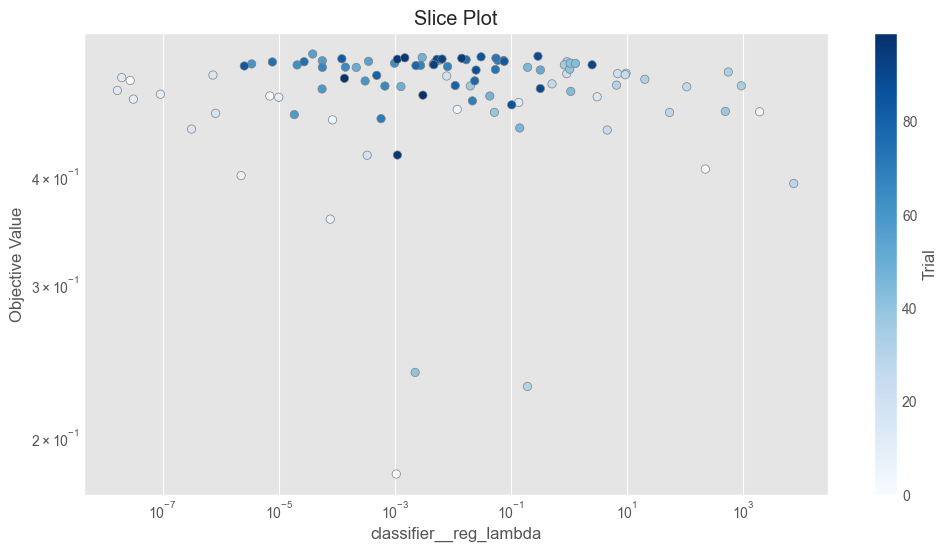

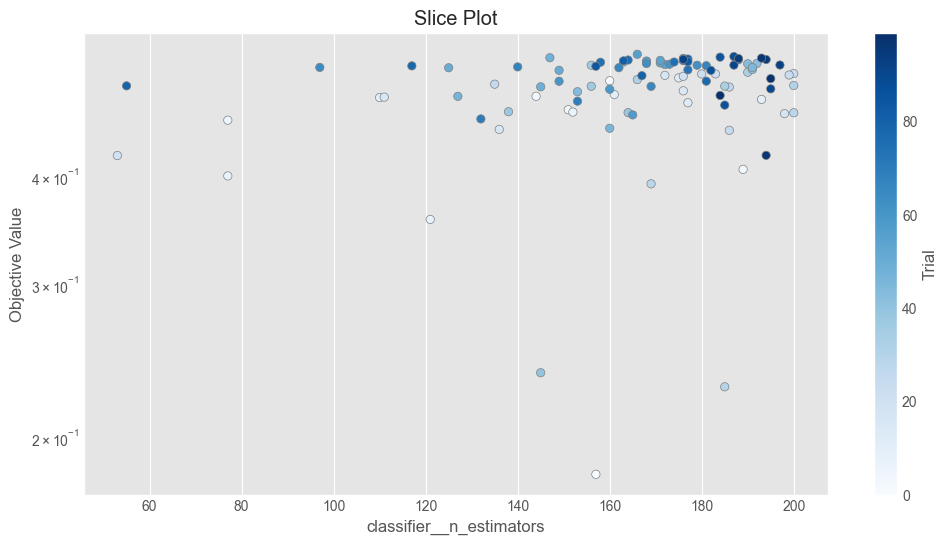

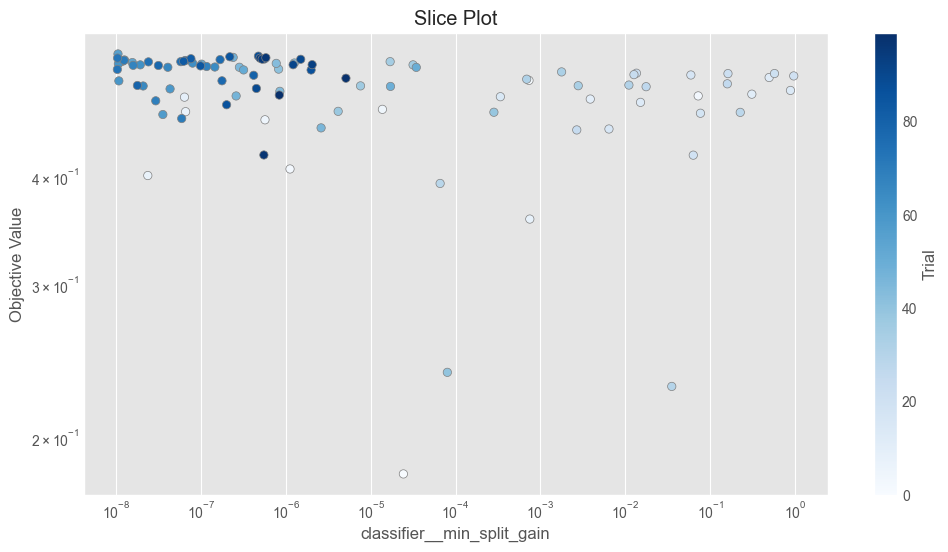

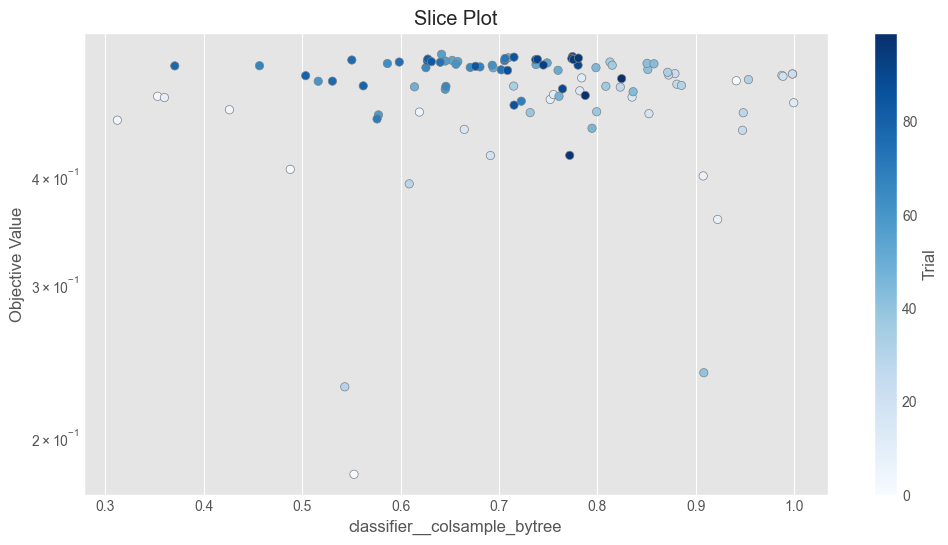

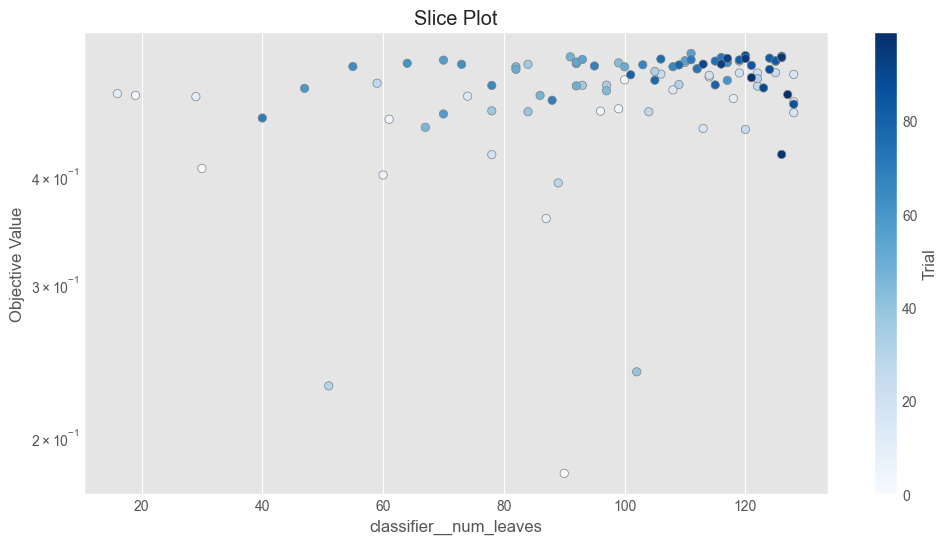

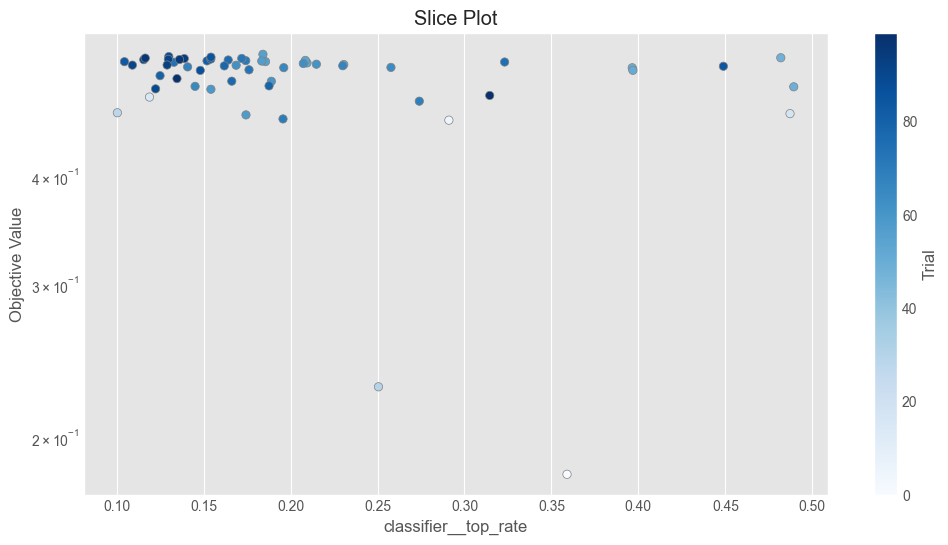

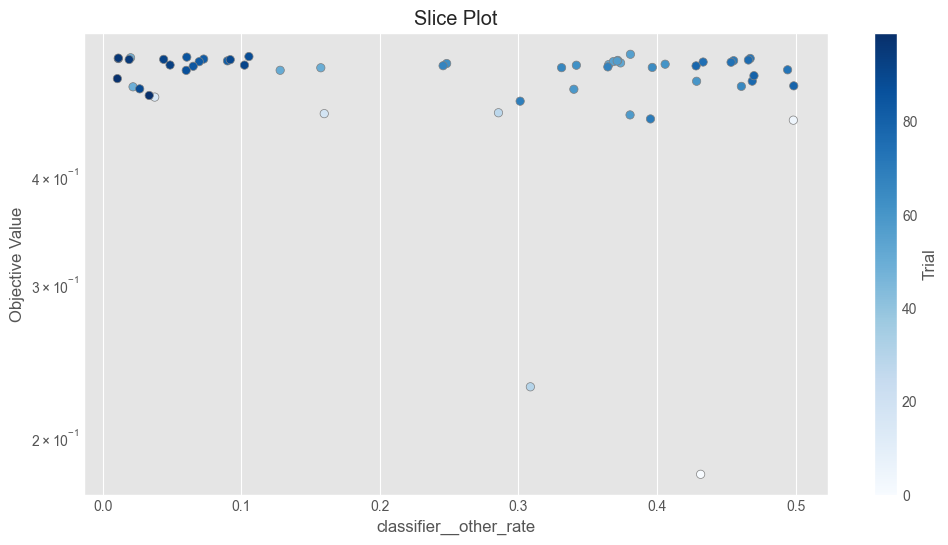

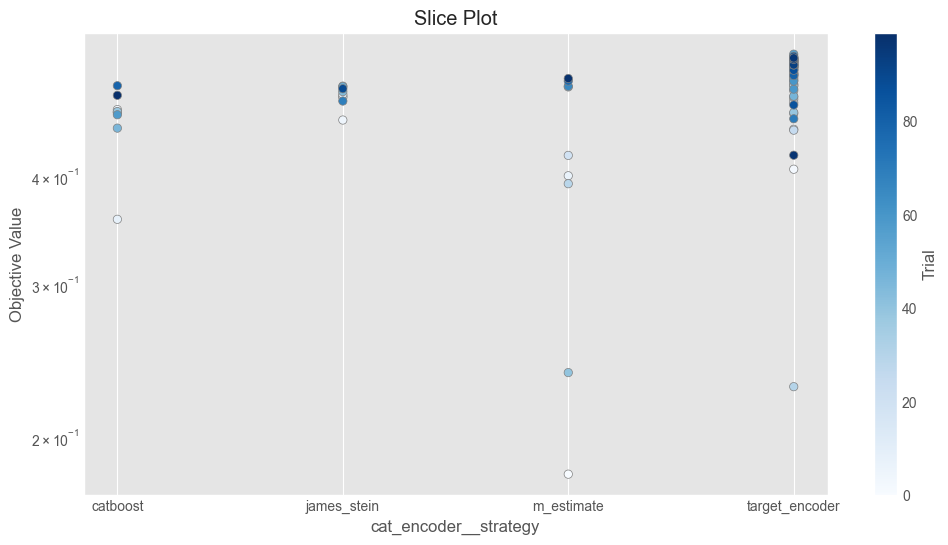


✅ Optimization complete!
Best parameters: {'classifier__boosting_type': 'goss', 'classifier__learning_rate': 0.07361804205513668, 'classifier__max_depth': 8, 'classifier__reg_alpha': 5.143443569535221e-07, 'classifier__reg_lambda': 3.838736308535599e-05, 'classifier__n_estimators': 166, 'classifier__min_split_gain': 1.0471657118126228e-08, 'classifier__colsample_bytree': 0.6417147630495295, 'classifier__num_leaves': 111, 'classifier__top_rate': 0.18410976659325012, 'classifier__other_rate': 0.3808023999284922, 'cat_encoder__strategy': 'target_encoder'}


In [8]:
RUN_HP_OPTIMIZATION = True  # Set to True to run optimization

if RUN_HP_OPTIMIZATION:
    from calibrated_clf.model_optimisation import optimize_model

    # Prepare data for optimization
    train_df = pd.concat([X_train, y_train.rename('isFraud')], axis=1)

    features = X_train.columns.tolist()
    categorical_features = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

    print("🔍 Running hyperparameter optimization with Optuna...")
    print(f"   Features: {len(features)}")
    print(f"   Categorical: {len(categorical_features)}")
    print(f"   Samples: {len(train_df):,}")

    # Run optimization — updates model_params for use in cells below
    # Use temporal CV to prevent leakage (StratifiedKFold on time-series data is wrong)
    train_groups = df.loc[X_train.index, 'time_group']

    _, model_params = optimize_model(
        train_val_data=train_df,
        features=features,
        categorical_features=categorical_features,
        study_name="fraud_detection_optimization",
        metric_name="average_precision",  # average_precision = AUC-PR (correct interpolation, preferred for imbalanced data)
        target_column_name='isFraud',
        n_trials=100,
        plot_report=True,
        groups=train_groups,   # temporal CV — prevents future data leaking into train folds
        gap_unique_groups=2,
    )

    print("\n✅ Optimization complete!")
    print(f"Best parameters: {model_params}")
else:
    print("⏩ Skipping hyperparameter optimization (using predefined params)")
    print("   Set RUN_HP_OPTIMIZATION = True to enable optimization")

In [9]:
MAKE_FEATURE_SELECTION = False  # Set to True to run recursive feature elimination

if MAKE_FEATURE_SELECTION:
    from feature_engine.selection import RecursiveFeatureElimination

    print("🔍 Running Recursive Feature Elimination...")
    print(f"   Starting features: {len(features)}")

    tmp_model = CalibratedBinaryClassifier(
        variable_params=model_params,
        calibration_method="none",
    )

    selector = RecursiveFeatureElimination(
        estimator=tmp_model,
        scoring="average_precision",
        cv=5,
        threshold=0.0,  # drop feature only if removal doesn't hurt performance
    )
    selector.fit(X_train[features], y_train)

    features_to_drop = selector.features_to_drop_
    features = [f for f in features if f not in features_to_drop]
    categorical_features = [f for f in categorical_features if f not in features_to_drop]
    X_train = X_train[features]
    X_test  = X_test[features]

    print(f"   Dropped {len(features_to_drop)} features: {features_to_drop}")
    print(f"   Remaining features: {len(features)}")
else:
    # Keep all features from the training set
    features = X_train.columns.tolist()
    categorical_features = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    print("⏩ Skipping feature selection (using all features)")
    print(f"   Features: {len(features)}")

⏩ Skipping feature selection (using all features)
   Features: 445


In [10]:
# 1. Isotonic calibration (temporal split: first 80% train, last 20% calibrate)
print("1️⃣ Training with Isotonic calibration...")
model_isotonic = CalibratedBinaryClassifier(
    variable_params=model_params,
    calibration_method='isotonic',
    calibration_params={'cal_size': 0.2, 'time_column': 'TransactionDT'}
)
model_isotonic.fit(X_train, y_train)
print("   ✓ Isotonic model trained")


1️⃣ Training with Isotonic calibration...
   ✓ Isotonic model trained


In [11]:
# 2. Venn-ABERS calibration (temporal split: first 80% train, last 20% calibrate)
print("\n2️⃣ Training with Venn-ABERS calibration...")
model_venn_abers = CalibratedBinaryClassifier(
    variable_params=model_params,
    calibration_method='venn_abers',
    calibration_params={'cal_size': 0.2, 'time_column': 'TransactionDT'}
)
model_venn_abers.fit(X_train, y_train)
print("   ✓ Venn-ABERS model trained")



2️⃣ Training with Venn-ABERS calibration...
   ✓ Venn-ABERS model trained


In [12]:
# 3. Sigmoid/Platt scaling (temporal split: first 80% train, last 20% calibrate)
print("\n3️⃣ Training with Sigmoid calibration...")
model_sigmoid = CalibratedBinaryClassifier(
    variable_params=model_params,
    calibration_method='sigmoid',
    calibration_params={'cal_size': 0.2, 'time_column': 'TransactionDT'}
)
model_sigmoid.fit(X_train, y_train)
print("   ✓ Sigmoid model trained\n")
print("✅ All models trained successfully!")



3️⃣ Training with Sigmoid calibration...
   ✓ Sigmoid model trained

✅ All models trained successfully!


## 4. Comprehensive Calibration Comparison

Let's do a **deep-dive comparison** of all three calibration methods across multiple dimensions.

In [13]:
# Get predictions from all calibration methods
predictions = {
    'Isotonic': model_isotonic.predict_proba(X_test)[:, 1],
    'Venn-ABERS': model_venn_abers.predict_proba(X_test)[:, 1],
    'Sigmoid': model_sigmoid.predict_proba(X_test)[:, 1],
}

# Uncalibrated baseline — trained on the same first 80% of X_train
# (same split that calibrated models use for the base learner)
# so the comparison is fair: all models see identical training data.
print("4️⃣ Training uncalibrated baseline (same time split)...")
n_cal = int(len(X_train) * 0.2)
X_train_sorted = X_train.sort_values('TransactionDT')
X_train_proper = X_train_sorted.iloc[:-n_cal]
y_train_proper = y_train.loc[X_train_proper.index]

model_no_calib = CalibratedBinaryClassifier(
    variable_params=model_params,
    calibration_method='none'
)
model_no_calib.fit(X_train_proper, y_train_proper)
predictions['Uncalibrated'] = model_no_calib.predict_proba(X_test)[:, 1]
print("   ✓ Uncalibrated baseline trained\n")
print("✅ All models ready for comparison! (fair: each trained on the same 80% of X_train)")


4️⃣ Training uncalibrated baseline (same time split)...
   ✓ Uncalibrated baseline trained

✅ All models ready for comparison! (fair: each trained on the same 80% of X_train)


In [14]:
# Compute detailed calibration metrics
def compute_calibration_metrics(y_true, y_pred, n_bins=10):
    """Compute comprehensive calibration metrics."""
    brier = brier_score_loss(y_true, y_pred)
    logloss = log_loss(y_true, y_pred)
    prob_true, prob_pred = calibration_curve(y_true, y_pred, n_bins=n_bins, strategy='quantile')
    ece = np.mean(np.abs(prob_true - prob_pred))
    bin_counts, _ = np.histogram(y_pred, bins=n_bins, range=(0, 1))
    bin_uniformity = np.std(bin_counts) / np.mean(bin_counts)
    return {
        'Brier Score': brier,
        'Log Loss': logloss,
        'ECE': ece,
        'Mean Confidence': y_pred.mean(),
        'Bin Uniformity': bin_uniformity
    }

calibration_results = []
for method, y_pred in predictions.items():
    metrics = compute_calibration_metrics(y_test, y_pred)
    metrics['Method'] = method
    calibration_results.append(metrics)

calib_df = pd.DataFrame(calibration_results)
calib_df = calib_df[['Method', 'Brier Score', 'Log Loss', 'ECE', 'Mean Confidence', 'Bin Uniformity']]

print("\n📊 Detailed Calibration Metrics Comparison:")
print("=" * 100)
print(calib_df.round(4).to_string(index=False))
print("=" * 100)
print("\n💡 Lower is better for: Brier Score, Log Loss, ECE, Bin Uniformity")
print("💡 Mean Confidence should be close to actual fraud rate ({:.4f})".format(y_test.mean()))


📊 Detailed Calibration Metrics Comparison:
      Method  Brier Score  Log Loss    ECE  Mean Confidence  Bin Uniformity
    Isotonic       0.0231    0.0955 0.0056           0.0391          2.7605
  Venn-ABERS       0.0231    0.0950 0.0061           0.0393          2.7548
     Sigmoid       0.0239    0.1051 0.0146           0.0387          2.8998
Uncalibrated       0.0229    0.0946 0.0024           0.0327          2.8207

💡 Lower is better for: Brier Score, Log Loss, ECE, Bin Uniformity
💡 Mean Confidence should be close to actual fraud rate (0.0346)


✅ Saved docs/metrics_heatmap.png


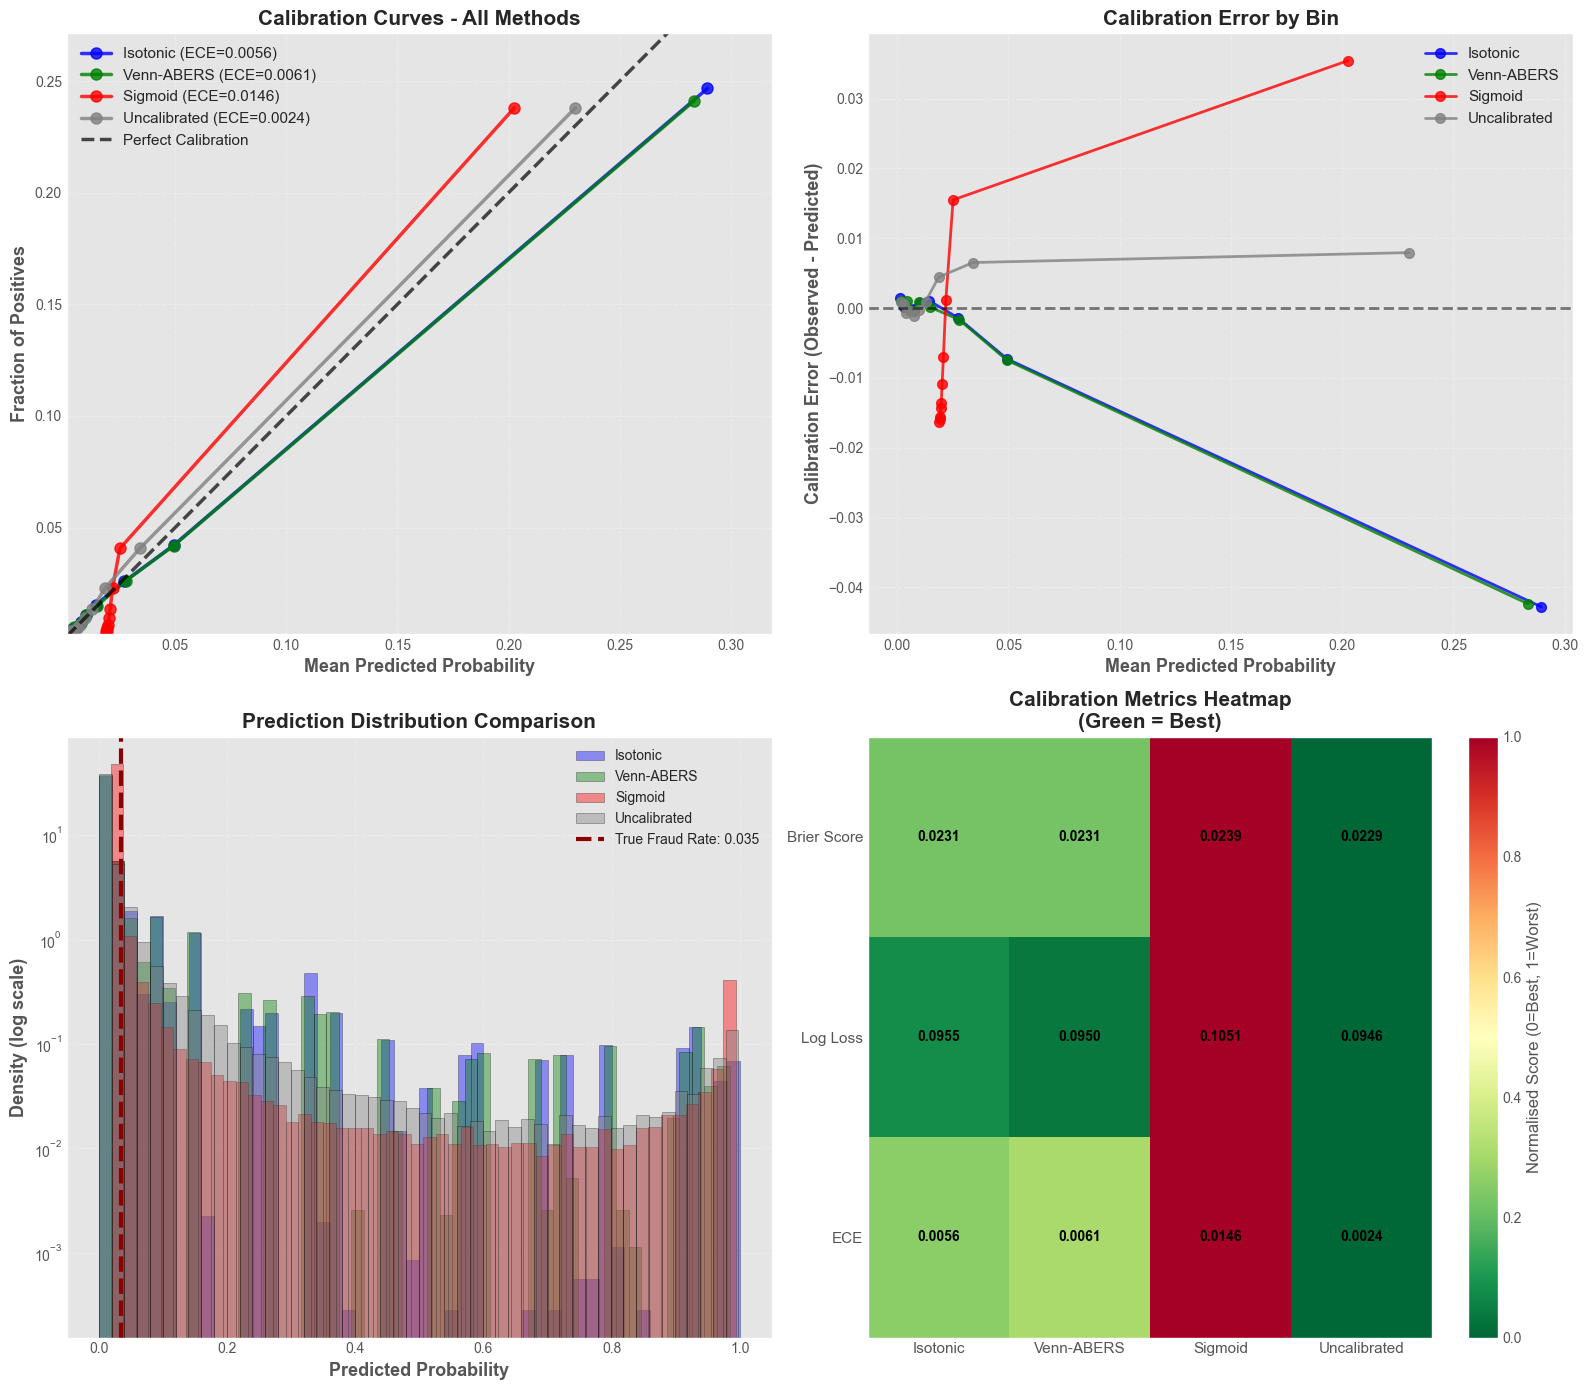


✅ Calibration curves compare:
   - Perfect calibration = diagonal line
   - Above diagonal = underconfident (predicting lower than reality)
   - Below diagonal = overconfident (predicting higher than reality)


In [15]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

colors = {'Isotonic': 'blue', 'Venn-ABERS': 'green', 'Sigmoid': 'red', 'Uncalibrated': 'gray'}

# Plot 1: Main Calibration Curves
ax1 = axes[0, 0]
_all_prob_pred, _all_prob_true = [], []

for method, y_pred in predictions.items():
    prob_true, prob_pred = calibration_curve(y_test, y_pred, n_bins=10, strategy='quantile')
    _all_prob_pred.extend(prob_pred)
    _all_prob_true.extend(prob_true)
    ece = np.mean(np.abs(prob_true - prob_pred))
    ax1.plot(
        prob_pred, prob_true,
        marker='o',
        label=f'{method} (ECE={ece:.4f})',
        color=colors[method],
        linewidth=2.5,
        markersize=8,
        alpha=0.8
    )

# Perfect calibration diagonal — only within actual data range
_x_min = min(_all_prob_pred) * 0.9
_x_max = max(_all_prob_pred) * 1.1
_y_min = min(_all_prob_true) * 0.9
_y_max = max(_all_prob_true) * 1.1
_plot_min = min(_x_min, _y_min)
_plot_max = max(_x_max, _y_max)
ax1.plot([_plot_min, _plot_max], [_plot_min, _plot_max],
         'k--', label='Perfect Calibration', linewidth=2.5, alpha=0.7)
ax1.set_xlim([_x_min, _x_max])
ax1.set_ylim([_y_min, _y_max])

ax1.set_xlabel('Mean Predicted Probability', fontsize=13, fontweight='bold')
ax1.set_ylabel('Fraction of Positives', fontsize=13, fontweight='bold')
ax1.set_title('Calibration Curves - All Methods', fontsize=15, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3, linestyle='--')

# Plot 2: Calibration Error per Bin
ax2 = axes[0, 1]

for method, y_pred in predictions.items():
    prob_true, prob_pred = calibration_curve(y_test, y_pred, n_bins=10, strategy='quantile')
    errors = prob_true - prob_pred
    ax2.plot(
        prob_pred, errors,
        marker='o',
        label=method,
        color=colors[method],
        linewidth=2,
        markersize=7,
        alpha=0.8
    )

ax2.axhline(0, color='k', linestyle='--', linewidth=2, alpha=0.5)
ax2.set_xlabel('Mean Predicted Probability', fontsize=13, fontweight='bold')
ax2.set_ylabel('Calibration Error (Observed - Predicted)', fontsize=13, fontweight='bold')
ax2.set_title('Calibration Error by Bin', fontsize=15, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3, linestyle='--')

# Plot 3: Prediction Distribution by Method
ax3 = axes[1, 0]
for method, y_pred in predictions.items():
    ax3.hist(
        y_pred,
        bins=50,
        alpha=0.4,
        label=method,
        color=colors[method],
        edgecolor='black',
        linewidth=0.5,
        density=True
    )

ax3.axvline(y_test.mean(), color='darkred', linestyle='--', linewidth=3,
            label=f'True Fraud Rate: {y_test.mean():.3f}')
ax3.set_yscale('log')
ax3.set_xlabel('Predicted Probability', fontsize=13, fontweight='bold')
ax3.set_ylabel('Density (log scale)', fontsize=13, fontweight='bold')
ax3.set_title('Prediction Distribution Comparison', fontsize=15, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3, linestyle='--')

# Plot 4: Calibration Metrics Heatmap (lower-is-better: green = best)
ax4 = axes[1, 1]
calib_cols = ['Brier Score', 'Log Loss', 'ECE']
metrics_for_heatmap = calib_df.set_index('Method')[calib_cols]
# For lower-is-better metrics: normalise so 0 = best (lowest), 1 = worst
metrics_normalized = (metrics_for_heatmap - metrics_for_heatmap.min()) / (
    metrics_for_heatmap.max() - metrics_for_heatmap.min() + 1e-12
)

im = ax4.imshow(metrics_normalized.T, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax4.grid(False)
ax4.set_xticks(np.arange(len(metrics_normalized.index)))
ax4.set_yticks(np.arange(len(metrics_normalized.columns)))
ax4.set_xticklabels(metrics_normalized.index, fontsize=11)
ax4.set_yticklabels(metrics_normalized.columns, fontsize=11)

for i in range(len(metrics_normalized.columns)):
    for j in range(len(metrics_normalized.index)):
        ax4.text(j, i, f'{metrics_for_heatmap.iloc[j, i]:.4f}',
                 ha="center", va="center", color="black", fontsize=10, fontweight='bold')

ax4.set_title('Calibration Metrics Heatmap\n(Green = Best)', fontsize=15, fontweight='bold')
plt.colorbar(im, ax=ax4, label='Normalised Score (0=Best, 1=Worst)')

plt.tight_layout()

# Save just the heatmap subplot (ax4) as a standalone PNG for the README
_fig_hm, _ax_hm = plt.subplots(figsize=(7, 3.5))
_im = _ax_hm.imshow(metrics_normalized.T, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
_ax_hm.grid(False)
_ax_hm.set_xticks(np.arange(len(metrics_normalized.index)))
_ax_hm.set_yticks(np.arange(len(metrics_normalized.columns)))
_ax_hm.set_xticklabels(metrics_normalized.index, fontsize=12)
_ax_hm.set_yticklabels(metrics_normalized.columns, fontsize=12)
for i in range(len(metrics_normalized.columns)):
    for j in range(len(metrics_normalized.index)):
        _ax_hm.text(j, i, f'{metrics_for_heatmap.iloc[j, i]:.4f}',
                    ha='center', va='center', color='black', fontsize=11, fontweight='bold')
_ax_hm.set_title('Calibration Metrics Heatmap  (Green = Best)', fontsize=13, fontweight='bold')
plt.colorbar(_im, ax=_ax_hm, label='Normalised Score (0=Best, 1=Worst)')
_fig_hm.tight_layout()
os.makedirs('docs', exist_ok=True)
_fig_hm.savefig('docs/metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.close(_fig_hm)
print("✅ Saved docs/metrics_heatmap.png")

plt.show()

print("\n✅ Calibration curves compare:")
print("   - Perfect calibration = diagonal line")
print("   - Above diagonal = underconfident (predicting lower than reality)")
print("   - Below diagonal = overconfident (predicting higher than reality)")

### 4.1 Detailed Calibration Metrics Comparison

Let's compare **calibration quality** using multiple metrics:
- **Brier Score**: Lower is better (measures both calibration and discrimination)
- **ECE (Expected Calibration Error)**: Lower is better (average calibration error across bins)
- **Log Loss**: Lower is better (penalizes confident wrong predictions)

In [16]:
# Compute comprehensive discriminative + calibration metrics
results = []
for method, y_pred in predictions.items():
    prob_true, prob_pred = calibration_curve(
        y_test, y_pred, n_bins=10, strategy='quantile'
    )
    ece = np.mean(np.abs(prob_true - prob_pred))

    results.append({
        'Method': method,
        'AUC-PR': average_precision_score(y_test, y_pred),
        'Brier Score': brier_score_loss(y_test, y_pred),
        'Log Loss': log_loss(y_test, y_pred),
        'ECE': ece,
    })

metrics_df = pd.DataFrame(results).round(4)
print("\n📊 Calibration Comparison Results:")
print("=" * 80)
print(metrics_df.to_string(index=False))
print("=" * 80)
print("\n💡 Lower is better for: Brier Score, Log Loss, ECE")
print("💡 Higher is better for: AUC-PR")


📊 Calibration Comparison Results:
      Method  AUC-PR  Brier Score  Log Loss    ECE
    Isotonic  0.4935       0.0231    0.0955 0.0056
  Venn-ABERS  0.4957       0.0231    0.0950 0.0061
     Sigmoid  0.5063       0.0239    0.1051 0.0146
Uncalibrated  0.5063       0.0229    0.0946 0.0024

💡 Lower is better for: Brier Score, Log Loss, ECE
💡 Higher is better for: AUC-PR


## 5. Visualization: Calibration Curves


✅ Saved docs/calibration_comparison.png


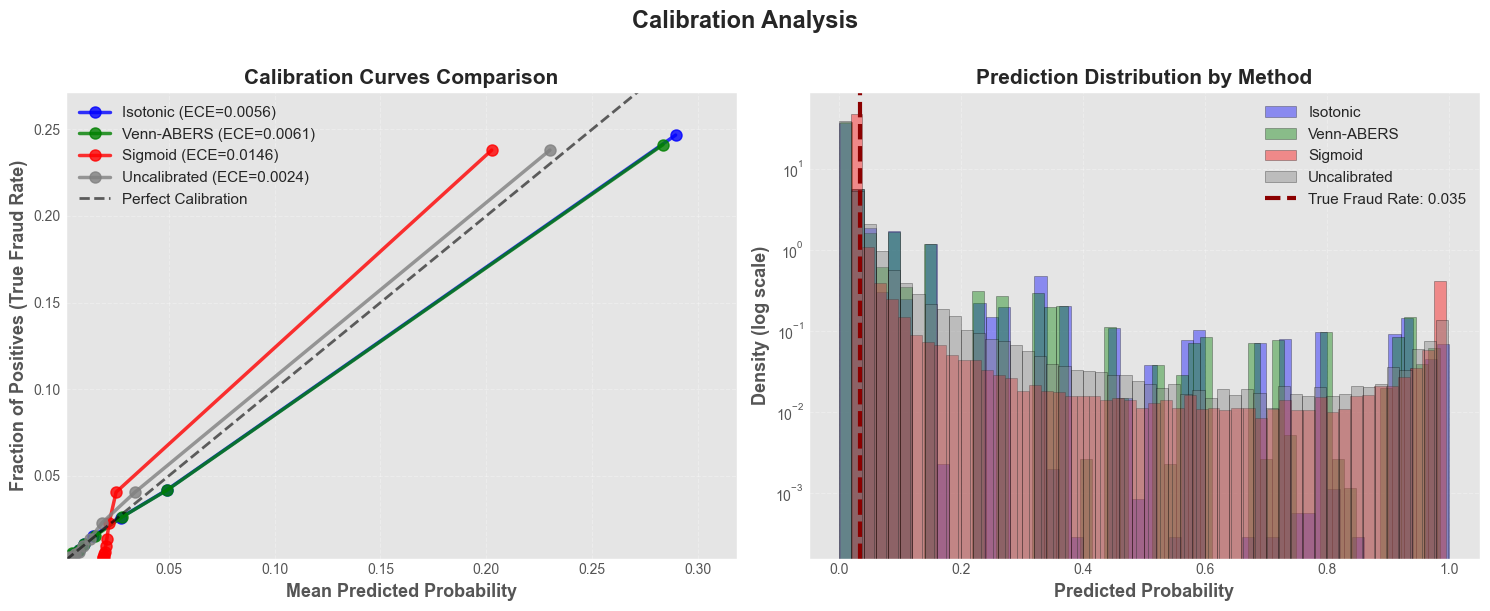

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = {'Isotonic': 'blue', 'Venn-ABERS': 'green', 'Sigmoid': 'red', 'Uncalibrated': 'gray'}

# Collect all calibration curve points to auto-scale axes
all_prob_pred, all_prob_true = [], []

# Plot 1: Calibration Curves
ax1 = axes[0]
for method, y_pred in predictions.items():
    prob_true, prob_pred = calibration_curve(
        y_test, y_pred, n_bins=10, strategy='quantile'
    )
    all_prob_pred.extend(prob_pred)
    all_prob_true.extend(prob_true)
    ece = np.mean(np.abs(prob_true - prob_pred))
    ax1.plot(
        prob_pred, prob_true,
        marker='o',
        label=f'{method} (ECE={ece:.4f})',
        linewidth=2.5,
        markersize=8,
        color=colors[method],
        alpha=0.8
    )

# Perfect calibration line — only within the actual data range
x_min = min(all_prob_pred) * 0.9
x_max = max(all_prob_pred) * 1.1
y_min = min(all_prob_true) * 0.9
y_max = max(all_prob_true) * 1.1
plot_min = min(x_min, y_min)
plot_max = max(x_max, y_max)
ax1.plot([plot_min, plot_max], [plot_min, plot_max],
         'k--', label='Perfect Calibration', linewidth=2, alpha=0.6)

ax1.set_xlim([x_min, x_max])
ax1.set_ylim([y_min, y_max])
ax1.set_xlabel('Mean Predicted Probability', fontsize=13, fontweight='bold')
ax1.set_ylabel('Fraction of Positives (True Fraud Rate)', fontsize=13, fontweight='bold')
ax1.set_title('Calibration Curves Comparison', fontsize=15, fontweight='bold')
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(alpha=0.3, linestyle='--')

# Plot 2: Prediction Distribution
ax2 = axes[1]
for method, y_pred in predictions.items():
    ax2.hist(
        y_pred,
        bins=50,
        alpha=0.4,
        label=method,
        density=True,
        color=colors[method],
        edgecolor='black',
        linewidth=0.5
    )

ax2.axvline(
    y_test.mean(),
    color='darkred',
    linestyle='--',
    linewidth=3,
    label=f'True Fraud Rate: {y_test.mean():.3f}'
)
ax2.set_yscale('log')
ax2.set_xlabel('Predicted Probability', fontsize=13, fontweight='bold')
ax2.set_ylabel('Density (log scale)', fontsize=13, fontweight='bold')
ax2.set_title('Prediction Distribution by Method', fontsize=15, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3, linestyle='--')

plt.suptitle('Calibration Analysis', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs('docs', exist_ok=True)
plt.savefig('docs/calibration_comparison.png', dpi=150, bbox_inches='tight')
print("\n✅ Saved docs/calibration_comparison.png")
plt.show()

## 6. Venn-ABERS Prediction Intervals

The key advantage of **Venn-ABERS** is that it provides **prediction intervals** [p_lower, p_upper] with mathematical guarantees:

- **p_lower**: Probability assuming the test object is class 0
- **p_upper**: Probability assuming the test object is class 1  
- **p_combined**: Combined probability = p_upper / (1 - p_lower + p_upper)
- **Interval width** (p_upper - p_lower): Measure of **uncertainty**

**Wide intervals indicate high uncertainty** → Flag for manual review!

In [18]:
# Get Venn-ABERS prediction intervals
va_intervals = model_venn_abers.predict_proba_with_intervals(X_test)

print("\n📊 Venn-ABERS Interval Statistics:")
print("=" * 60)
print(f"Mean interval width:   {va_intervals['interval_width'].mean():.4f}")
print(f"Median interval width: {np.median(va_intervals['interval_width']):.4f}")
print(f"Max interval width:    {va_intervals['interval_width'].max():.4f}")
print(f"Min interval width:    {va_intervals['interval_width'].min():.4f}")
print(f"\nPredictions with width > 0.1: {(va_intervals['interval_width'] > 0.1).sum():,} "
      f"({(va_intervals['interval_width'] > 0.1).mean()*100:.1f}%)")
print("=" * 60)


📊 Venn-ABERS Interval Statistics:
Mean interval width:   0.0007
Median interval width: 0.0002
Max interval width:    0.1205
Min interval width:    0.0001

Predictions with width > 0.1: 9 (0.0%)


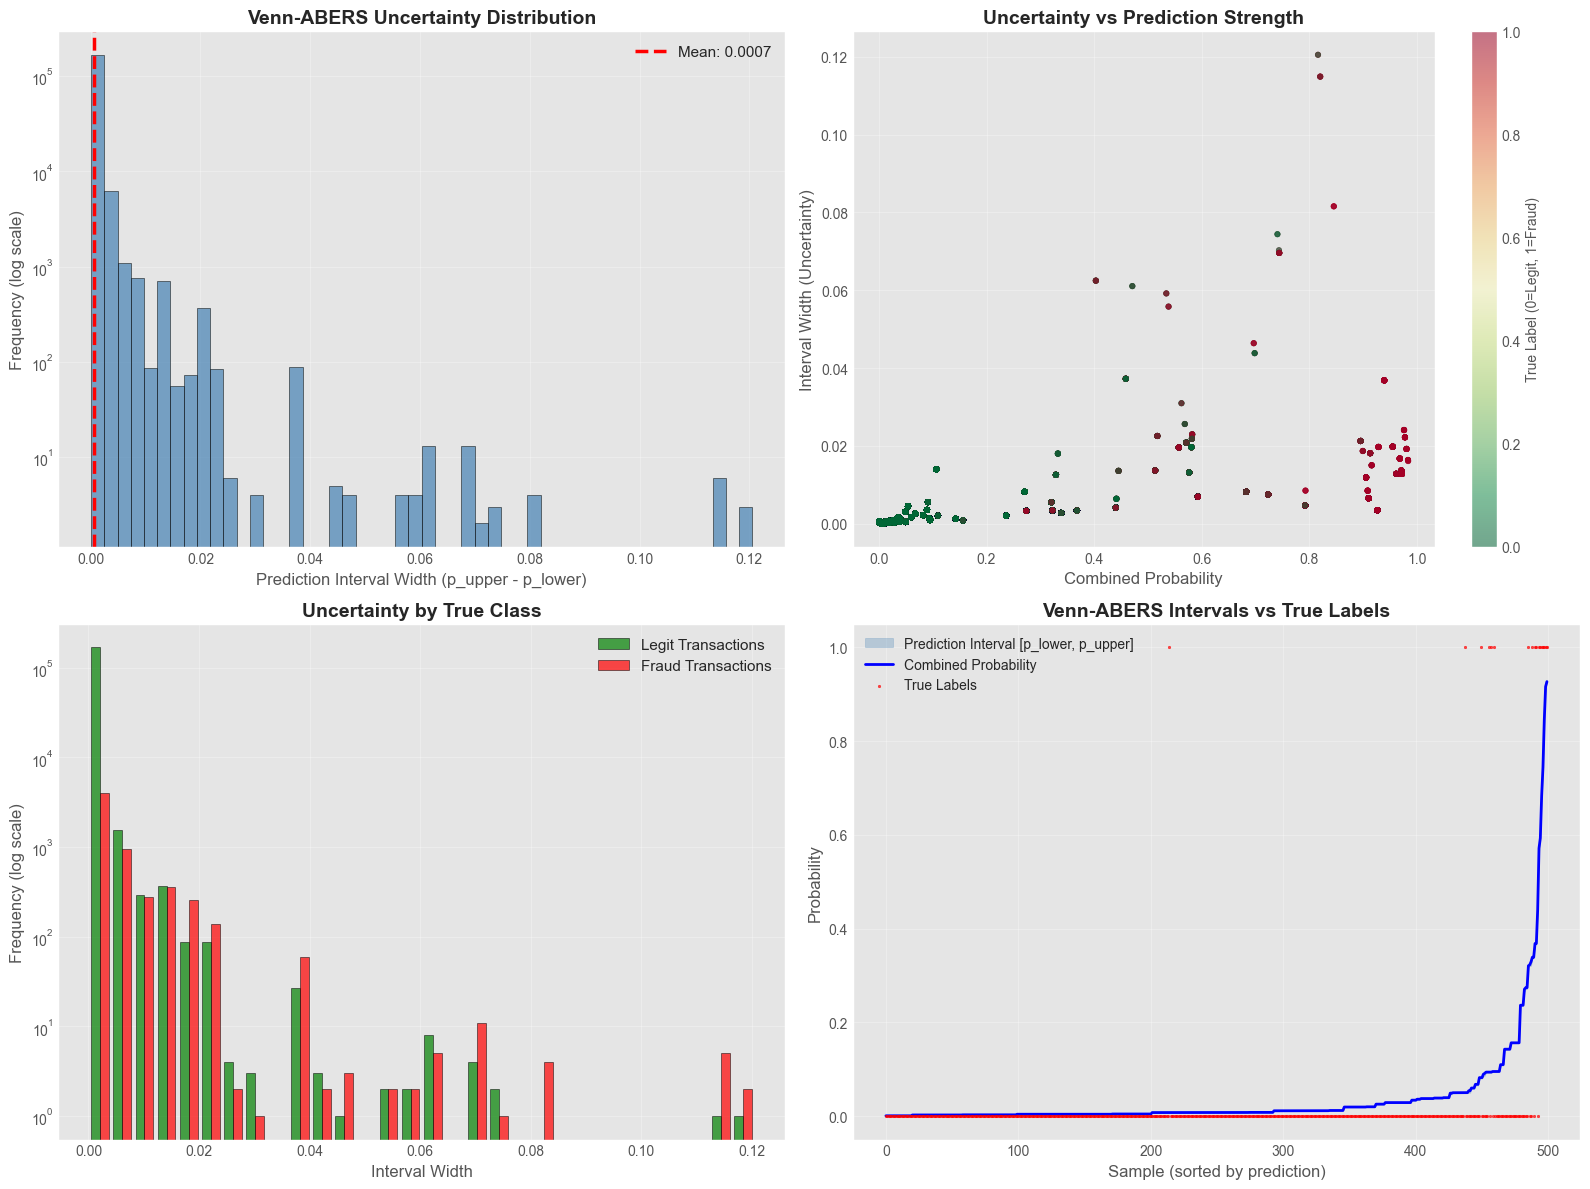

In [19]:
# Visualize Venn-ABERS intervals
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Interval Width Distribution
ax1 = axes[0, 0]
ax1.hist(
    va_intervals['interval_width'],
    bins=50,
    edgecolor='black',
    alpha=0.7,
    color='steelblue'
)
ax1.axvline(
    va_intervals['interval_width'].mean(),
    color='red',
    linestyle='--',
    linewidth=2.5,
    label=f'Mean: {va_intervals["interval_width"].mean():.4f}'
)
ax1.set_yscale('log')
ax1.set_xlabel('Prediction Interval Width (p_upper - p_lower)', fontsize=12)
ax1.set_ylabel('Frequency (log scale)', fontsize=12)
ax1.set_title('Venn-ABERS Uncertainty Distribution', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Plot 2: Interval Width vs Combined Probability
ax2 = axes[0, 1]
scatter = ax2.scatter(
    va_intervals['p_combined'],
    va_intervals['interval_width'],
    c=y_test.values,
    cmap='RdYlGn_r',
    alpha=0.5,
    s=15
)
ax2.set_xlabel('Combined Probability', fontsize=12)
ax2.set_ylabel('Interval Width (Uncertainty)', fontsize=12)
ax2.set_title('Uncertainty vs Prediction Strength', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('True Label (0=Legit, 1=Fraud)', fontsize=10)
ax2.grid(alpha=0.3)

# Plot 3: Interval Width by True Label
ax3 = axes[1, 0]
fraud = va_intervals['interval_width'][y_test == 1]
non_fraud = va_intervals['interval_width'][y_test == 0]
ax3.hist(
    [non_fraud, fraud],
    bins=30,
    label=['Legit Transactions', 'Fraud Transactions'],
    alpha=0.7,
    edgecolor='black',
    color=['green', 'red']
)
ax3.set_yscale('log')
ax3.set_xlabel('Interval Width', fontsize=12)
ax3.set_ylabel('Frequency (log scale)', fontsize=12)
ax3.set_title('Uncertainty by True Class', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(alpha=0.3)

# Plot 4: Sample of Prediction Intervals
ax4 = axes[1, 1]
sorted_indices = np.argsort(va_intervals['p_combined'])
sample_size = min(500, len(sorted_indices))
sample_indices = sorted_indices[::max(1, len(sorted_indices) // sample_size)][:sample_size]

x = np.arange(len(sample_indices))
ax4.fill_between(
    x,
    va_intervals['p_lower'][sample_indices],
    va_intervals['p_upper'][sample_indices],
    alpha=0.3,
    color='steelblue',
    label='Prediction Interval [p_lower, p_upper]'
)
ax4.plot(
    x,
    va_intervals['p_combined'][sample_indices],
    'b-',
    linewidth=2,
    label='Combined Probability'
)
ax4.scatter(
    x,
    y_test.values[sample_indices],
    c='red',
    s=3,
    alpha=0.7,
    label='True Labels',
    zorder=3
)

ax4.set_xlabel('Sample (sorted by prediction)', fontsize=12)
ax4.set_ylabel('Probability', fontsize=12)
ax4.set_title('Venn-ABERS Intervals vs True Labels', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Decision Framework with Uncertainty

Use prediction intervals to create a **risk-based decision framework**:

In [20]:
# Define decision thresholds
LOW_RISK_THRESHOLD = 0.1
HIGH_RISK_THRESHOLD = 0.5
UNCERTAINTY_THRESHOLD = 0.1

# Raw flags (can overlap — e.g. low_risk & uncertain both true)
_low_risk_raw  = va_intervals['p_upper'] < LOW_RISK_THRESHOLD
_high_risk_raw = va_intervals['p_lower'] > HIGH_RISK_THRESHOLD
_uncertain_raw = va_intervals['interval_width'] > UNCERTAINTY_THRESHOLD

# Apply priority: High Risk > Low Risk > Uncertain > Medium
# (matches the decision logic used in the sample table below)
high_risk   = _high_risk_raw
low_risk    = _low_risk_raw  & ~high_risk
uncertain   = _uncertain_raw & ~high_risk & ~low_risk
medium_risk = ~high_risk & ~low_risk & ~uncertain

print("\n🚦 Decision Framework Based on Venn-ABERS Intervals:")
print("=" * 70)
print(f"✅ Auto-Approve (low risk):        {low_risk.sum():6,} transactions ({low_risk.mean()*100:5.1f}%)")
print(f"🚨 Auto-Block (high risk):         {high_risk.sum():6,} transactions ({high_risk.mean()*100:5.1f}%)")
print(f"❓ Manual Review (uncertain):      {uncertain.sum():6,} transactions ({uncertain.mean()*100:5.1f}%)")
print(f"⚠️  Standard Review (medium risk): {medium_risk.sum():6,} transactions ({medium_risk.mean()*100:5.1f}%)")
total = low_risk.sum() + high_risk.sum() + uncertain.sum() + medium_risk.sum()
print(f"{'Total:':<42} {total:6,} ({total / len(low_risk) * 100:5.1f}%)")
print("=" * 70)

# Check fraud rates in each category
print("\n📊 Fraud Rates by Decision Category:")
print("=" * 70)
if low_risk.sum() > 0:
    print(f"Auto-Approve:     {y_test[low_risk].mean()*100:.2f}% fraud (should be very low)")
if high_risk.sum() > 0:
    print(f"Auto-Block:       {y_test[high_risk].mean()*100:.2f}% fraud (should be very high)")
if uncertain.sum() > 0:
    print(f"Manual Review:    {y_test[uncertain].mean()*100:.2f}% fraud (needs human judgment)")
if medium_risk.sum() > 0:
    print(f"Standard Review:  {y_test[medium_risk].mean()*100:.2f}% fraud (moderate risk)")
print("=" * 70)



🚦 Decision Framework Based on Venn-ABERS Intervals:
✅ Auto-Approve (low risk):        164,065 transactions ( 92.6%)
🚨 Auto-Block (high risk):          2,896 transactions (  1.6%)
❓ Manual Review (uncertain):           0 transactions (  0.0%)
⚠️  Standard Review (medium risk): 10,201 transactions (  5.8%)
Total:                                     177,162 (100.0%)

📊 Fraud Rates by Decision Category:
Auto-Approve:     1.37% fraud (should be very low)
Auto-Block:       73.55% fraud (should be very high)
Standard Review:  17.09% fraud (moderate risk)


## 8. Key Takeaways

### ✅ **When to Use Each Calibration Method:**

**Isotonic Regression:**
- ✅ Standard method, fast and reliable
- ✅ Good for large datasets
- ✅ Sufficient when point estimates are adequate

**Venn-ABERS:**
- ✅ **High-stakes decisions** (fraud, medical, loans)
- ✅ **Uncertainty quantification** beyond point estimates
- ✅ **Distribution-free guarantees** (no assumptions)
- ✅ **Alert systems** where wide intervals trigger human review
- ✅ **Better interpretability** with prediction intervals

**Sigmoid (Platt Scaling):**
- ✅ Fast, parametric method
- ⚠️ Assumes sigmoid relationship (less flexible)
- ✅ Can work well with small calibration sets

### 🎯 **Production Recommendations:**

1. **For fraud detection:** Use Venn-ABERS to flag uncertain cases for review
2. **Monitor interval widths:** Increasing widths may indicate data drift
3. **Set decision thresholds** based on business costs (false positives vs false negatives)
4. **Use AUC-PR** over AUC-ROC for imbalanced data (3.5% fraud rate)
5. **Temporal validation** is critical - always test on future data!

---

**🚀 This framework is production-ready and showcases:**
- ✨ Advanced calibration with mathematical guarantees
- 📊 Proper metrics for imbalanced data
- 🔍 Uncertainty quantification for risk management
- ⏱️ Temporal validation to prevent data leakage
- 🎯 Real-world fraud detection application